# Car price — XGBoost
Data, model-name cleanup and train/val/test split come from `tree_data.py` = identical to `linear_regression.ipynb` sections 1–2.

- Features: engine_capacity, mileage, car_age + brand, model, fuel_type, gear_type, color (native categorical splits). No `OTHER_*` grouping — trees split on the cleaned model name directly.
- Target = `log(price)`; metrics on the price scale. No assumption tests (trees do not assume linearity / normal / constant-variance residuals).

In [1]:
import time, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import config as C
from tree_data import get_data, pick, tune_row, test_table, plot_test, importance, error_tables

pd.set_option("display.width", 200, "display.max_columns", 50)
train, val, test, X = get_data(codes=False)
y_log = np.log(train[C.TARGET])
print({k: len(v) for k, v in X.items()}, X['train'].shape)

removed 287 rows with car_age > 25


{'train': 20872, 'val': 4472, 'test': 4473} (20872, 8)


## 1. Tune on validation
Small grid; the test set is not touched here. `gap` = val MAE / train MAE (1 = no overfit).

Selection (`tree_data.pick`): among configs within 2% of the best val MAE, take the one with the smallest gap — near-best accuracy, least overfit.

In [2]:
rows, models = [], []
for p in [dict(max_depth=d, min_child_weight=w, reg_lambda=r) for d in [6, 8] for w in [5, 20] for r in [1, 10]]:
    m = XGBRegressor(n_estimators=5000, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, **p,
                     enable_categorical=True, tree_method='hist', max_cat_to_onehot=1,
                     early_stopping_rounds=200, random_state=C.SEED, n_jobs=-1)
    t = time.time()
    # ponytail: same val set for early stopping + model choice, use CV if the gap to test matters
    m.fit(X['train'], y_log, eval_set=[(X['val'], np.log(val[C.TARGET]))], verbose=False)
    r = tune_row(m, X, train, val, params=str(p), sec=round(time.time() - t, 1))
    rows.append(r); models.append(m)
tune = pd.DataFrame(rows).drop(columns='model')
tune.sort_values('MAE').round(4)

,RMSE,MAE,MAPE,R2,params,sec,train_MAE,gap
4,195339.9734,67703.9219,0.1063,0.9180,"{'max_depth': 8, 'min_child_weight': 5, 'reg_l...",4.2,46267.7734,1.4633
6,205464.8708,68101.4688,0.1064,0.9093,"{'max_depth': 8, 'min_child_weight': 20, 'reg_...",5.2,49930.3633,1.3639
5,189213.1398,68136.0547,0.1075,0.9230,"{'max_depth': 8, 'min_child_weight': 5, 'reg_l...",5.8,46553.7344,1.4636
7,192813.1899,68145.3203,0.1075,0.9201,"{'max_depth': 8, 'min_child_weight': 20, 'reg_...",7.6,51089.6641,1.3338
3,198973.4268,68783.6172,0.1080,0.9149,"{'max_depth': 6, 'min_child_weight': 20, 'reg_...",13.1,50513.9609,1.3617
0,202863.7167,68883.5234,0.1078,0.9115,"{'max_depth': 6, 'min_child_weight': 5, 'reg_l...",8.8,52405.5977,1.3144
1,193702.2566,68995.7031,0.1081,0.9193,"{'max_depth': 6, 'min_child_weight': 5, 'reg_l...",18.2,47389.7109,1.4559
2,203482.8142,69203.6094,0.1082,0.9110,"{'max_depth': 6, 'min_child_weight': 20, 'reg_...",11.3,52216.8008,1.3253


## 2. Best params → evaluate test once

In [3]:
i = pick(tune); best = models[i]
tune.loc[i, 'params'] += f" n_trees={models[i].best_iteration + 1}"
pred_te, res = test_table('XGBoost', best, X, test, tune, i)
res

,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
XGBoost,156037.0926,66754.8906,0.1096,0.9374,"{'max_depth': 6, 'min_child_weight': 5, 'reg_l...",52405.5977,68883.5234,0.9115
MLR final (from LR notebook),192232.0000,85432.0000,0.1380,0.9050,NaN,NaN,NaN,NaN


## 3. Actual vs predicted (test, price scale)

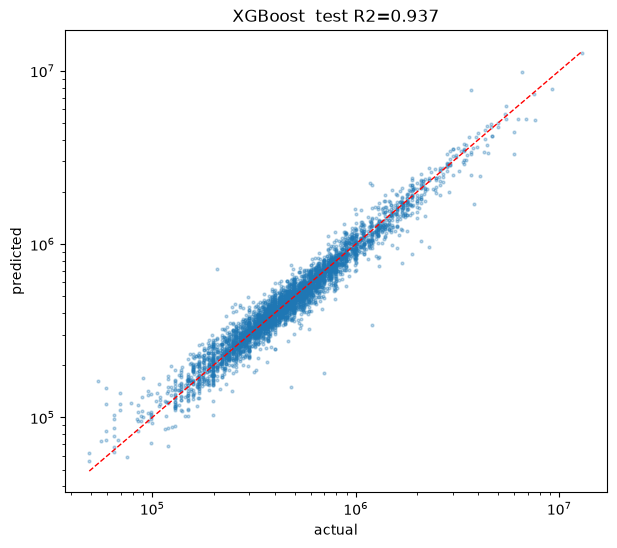

In [4]:
plot_test('XGBoost', test, pred_te)

## 4. Feature importance
Built-in (impurity/gain) importance is biased toward high-cardinality features (`model` ~490 levels), so permutation importance on validation is shown next to it.

In [5]:
importance(best, X, val, n_jobs=None)

,built-in,permutation (val)
model,0.307,0.547
car_age,0.290,0.387
mileage,0.028,0.023
engine_capacity,0.092,0.015
brand,0.136,0.013
gear_type,0.084,0.009
fuel_type,0.057,0.004
color,0.006,0.002


## 5. Where is the error? (validation, price scale)

In [6]:
by_age, by_model = error_tables(best, X, val)
display(by_age)
by_model

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",245,168662.744,0.100
"(2, 5]",1264,83388.625,0.094
"(5, 8]",1352,59384.559,0.098
"(8, 12]",964,55511.660,0.109
"(12, 16]",461,41590.120,0.146
"(16, 20]",126,43859.375,0.170
"(20, 25]",60,47016.821,0.201


n         MAE   MAPE  med_price
brand         model                                     
PORSCHE       CAYENNE   27  337516.748  0.115  2990000.0
MERCEDES-BENZ E300      19  242525.273  0.182  1259000.0
              E220      10  226082.303  0.225  1009500.0
              C220      15  212149.019  0.159  1150000.0
TOYOTA        ALPHARD   57  164384.606  0.094  1780000.0
BMW           X5        13  148917.385  0.084  1860000.0
              320D      11  143509.960  0.132   619000.0
HYUNDAI       STARIA    12  143282.714  0.108  1024500.0
MINI          COOPER    16  138354.924  0.138   496500.0
BMW           330E      23  136409.595  0.141   998000.0
              X3        12  127558.438  0.186   604000.0
TOYOTA        VELLFIRE  50  117615.966  0.096  1344000.0
MERCEDES-BENZ C350      16  114546.896  0.151   569500.0
              C300      14  109904.388  0.109   879000.0
FORD          EVEREST   71  108276.157  0.128   743000.0